In [111]:
import numpy as np
from vix_ibkr import IBKR
from vix_config import *
from vix_strategy import *

util.startLoop()

In [112]:
from vix_ibkr import IBKR

# VIXContractManager

In [43]:
class VIXContractManager:
    """
    Manages VIX futures contract resolution on IBKR.
    VIX futures trade on CFE (Cboe Futures Exchange).
    Handles finding the correct front-month (VX1) and second-month (VX2) contracts.
    """

    def __init__(self, ib: IB):
        self.ib = ib

    def get_vix_futures_chain(self) -> list:
        """
        Fetch all available VIX futures contracts from IBKR, sorted by expiry.
        Returns list of Contract objects sorted by lastTradeDateOrContractMonth.
        """
        # Generic VIX future on CFE
        vix_fut = Future(symbol='VIX', exchange='CFE', currency='USD')
        details = self.ib.ib.reqContractDetails(vix_fut)

        if not details:
            print("[ERROR] No VIX futures contracts found. Check market data subscriptions.")
            return []

        # Extract contracts and sort by expiry
        contracts = []
        for d in details:
            c = d.contract
            contracts.append(c)

        contracts.sort(key=lambda c: c.lastTradeDateOrContractMonth)
        return contracts

    def get_front_and_second_month(self) -> tuple:
        """
        Returns (VX1_contract, VX2_contract) — the two nearest-expiry standard monthly VIX futures.
        Filters out weekly contracts and contracts that have already expired.
        """
        chain = self.get_vix_futures_chain()
        today = datetime.now().strftime('%Y%m%d')

        # Filter: only standard monthly contracts (tradingClass='VX') with future expiry
        active = [c for c in chain 
                  if c.lastTradeDateOrContractMonth >= today 
                  and c.tradingClass == 'VX']

        if len(active) < 2:
            print(f"[ERROR] Need at least 2 active VIX futures, found {len(active)}")
            return None, None

        vx1 = active[0]  # Front month
        vx2 = active[1]  # Second month

        # Qualify contracts with IBKR
        self.ib.ib.qualifyContracts(vx1)
        self.ib.ib.qualifyContracts(vx2)

        print(f"[CONTRACTS] VX1: {vx1.localSymbol} (exp: {vx1.lastTradeDateOrContractMonth})")
        print(f"[CONTRACTS] VX2: {vx2.localSymbol} (exp: {vx2.lastTradeDateOrContractMonth})")

        return vx1, vx2

    def get_vix_index(self) -> Index:
        """Returns the CBOE VIX spot index contract for regime filtering."""
        vix = Index('VIX', 'CBOE', 'USD')
        self.ib.ib.qualifyContracts(vix)
        return vix

    def days_to_expiry(self, contract) -> int:
        """Calculate days until contract expiry."""
        exp = datetime.strptime(contract.lastTradeDateOrContractMonth, '%Y%m%d')
        return (exp - datetime.now()).days

In [44]:
ib = IBKR()
ib.connect(np.random.randint(100000, 999999), isTWS=True)

In [45]:
x = VIXContractManager(ib)
c = x.get_vix_futures_chain()
c

[Contract(secType='FUT', conId=852182801, symbol='VIX', lastTradeDateOrContractMonth='20260325', multiplier='1000', exchange='CFE', currency='USD', localSymbol='VX12H6', tradingClass='VX12'),
 Contract(secType='FUT', conId=854140649, symbol='VIX', lastTradeDateOrContractMonth='20260401', multiplier='1000', exchange='CFE', currency='USD', localSymbol='VX13J6', tradingClass='VX13'),
 Contract(secType='FUT', conId=858536101, symbol='VIX', lastTradeDateOrContractMonth='20260408', multiplier='1000', exchange='CFE', currency='USD', localSymbol='VX14J6', tradingClass='VX14'),
 Contract(secType='FUT', conId=800674914, symbol='VIX', lastTradeDateOrContractMonth='20260415', multiplier='1000', exchange='CFE', currency='USD', localSymbol='VXJ6', tradingClass='VX'),
 Contract(secType='FUT', conId=860525095, symbol='VIX', lastTradeDateOrContractMonth='20260422', multiplier='1000', exchange='CFE', currency='USD', localSymbol='VX16J6', tradingClass='VX16'),
 Contract(secType='FUT', conId=863325319, sy

In [46]:
vx1, vx2 = x.get_front_and_second_month()
print(f"VX1: {vx1}, VX2: {vx2}")

[CONTRACTS] VX1: VXJ6 (exp: 20260415)
[CONTRACTS] VX2: VXK6 (exp: 20260519)
VX1: Contract(secType='FUT', conId=800674914, symbol='VIX', lastTradeDateOrContractMonth='20260415', multiplier='1000', exchange='CFE', currency='USD', localSymbol='VXJ6', tradingClass='VX'), VX2: Contract(secType='FUT', conId=809537188, symbol='VIX', lastTradeDateOrContractMonth='20260519', multiplier='1000', exchange='CFE', currency='USD', localSymbol='VXK6', tradingClass='VX')


In [47]:
vix = x.get_vix_index()
print(f"VIX Index: {vix}")

VIX Index: Index(conId=13455763, symbol='VIX', exchange='CBOE', currency='USD', localSymbol='VIX')


In [48]:
x.days_to_expiry(vx1)

23

In [52]:
class VIXDataEngine:
    """
    Fetches VIX spot, VX1/VX2 prices, and maintains a rolling spread history
    for z-score computation. Uses IBKR wrapper for data fetching.
    """
    def __init__(self, ibkr: IBKR, contract_mgr: VIXContractManager):
        self.ibkr = ibkr
        self.contract_mgr = contract_mgr
        self.spread_history = pd.DataFrame()  # columns: date, vx1, vx2, spread, vix_spot
        self._state_file = Path("vix_spread_history.csv")

    def load_state(self):
        """Load persisted spread history from disk."""
        if self._state_file.exists():
            self.spread_history = pd.read_csv(self._state_file, parse_dates=['date'], index_col='date')
            print(f"[DATA] Loaded {len(self.spread_history)} days of spread history from disk.")
        else:
            print("[DATA] No prior spread history found. Will build from scratch.")

    def save_state(self):
        """Persist spread history to disk for continuity across restarts."""
        if not self.spread_history.empty:
            self.spread_history.to_csv(self._state_file)
            print(f"[DATA] Saved {len(self.spread_history)} days of spread history.")

    def fetch_historical_bars(self, contract, duration: str = DATA_DURATION, bar_size: str = DATA_BAR_SIZE) -> pd.DataFrame:
        """Fetch historical OHLCV bars."""
        return self.ibkr.get_historical_prices(contract, duration=duration, bar_size=bar_size)

    def fetch_current_price(self, contract) -> float:
        """Fetch real-time (or delayed) price."""
        return self.ibkr.get_current_price(contract)

    def build_spread_history(self, vx1_contract, vx2_contract) -> pd.DataFrame:
        """
        Build historical spread series from VX1 and VX2 close prices.
        Merges on date, computes spread = VX2 - VX1.
        """
        print("[DATA] Fetching VX1 historical data...")
        df_vx1 = self.fetch_historical_bars(vx1_contract)

        print("[DATA] Fetching VX2 historical data...")
        df_vx2 = self.fetch_historical_bars(vx2_contract)

        if df_vx1.empty or df_vx2.empty:
            print("[ERROR] Cannot build spread — missing historical data.")
            return pd.DataFrame()

        # Merge on date
        spread_df = pd.DataFrame({
            'vx1': df_vx1['close'],
            'vx2': df_vx2['close']
        }).dropna()

        spread_df['spread'] = spread_df['vx2'] - spread_df['vx1']
        spread_df.index.name = 'date'

        print(f"[DATA] Built spread history: {len(spread_df)} days, "
              f"spread range [{spread_df['spread'].min():.2f}, {spread_df['spread'].max():.2f}]")

        return spread_df

    def _fetch_vix_yfinance(self) -> float:
        """Fetch near-real-time VIX spot from Yahoo Finance (no subscription needed)."""
        try:
            vix = yf.Ticker("^VIX")
            price = vix.fast_info.get('lastPrice', float('nan'))
            if price and not math.isnan(price):
                print(f"[DATA] VIX spot from yfinance: {price:.2f}")
                return price
        except Exception as e:
            print(f"[WARN] yfinance VIX fetch failed: {e}")
        return float('nan')

    def fetch_vix_spot(self) -> float:
        """
        Fetch current VIX spot level for regime filtering.
        Primary: yfinance (near-real-time, no subscription).
        Fallback: IBKR delayed data.
        """
        # Primary — yfinance
        price = self._fetch_vix_yfinance()
        if not math.isnan(price):
            return price

        # Fallback — IBKR
        print("[DATA] yfinance unavailable, falling back to IBKR delayed data.")
        vix_index = self.contract_mgr.get_vix_index()
        try:
            price = self.ibkr.get_current_price(vix_index)
            return price
        except Exception:
            print("[WARN] Could not get VIX spot from either source. Defaulting to 20.0 (neutral).")
            return 20.0

    def update_spread_today(self, vx1_price: float, vx2_price: float, vix_spot: float):
        """Append today's data point to the spread history."""
        today = pd.Timestamp(datetime.now().date())

        new_row = pd.DataFrame({
            'vx1': [vx1_price],
            'vx2': [vx2_price],
            'spread': [vx2_price - vx1_price],
            'vix_spot': [vix_spot]
        }, index=pd.DatetimeIndex([today], name='date'))

        # Avoid duplicate dates
        if not self.spread_history.empty and today in self.spread_history.index:
            self.spread_history.loc[today] = new_row.iloc[0]
        else:
            self.spread_history = pd.concat([self.spread_history, new_row])

        # Trim to keep only recent history
        max_rows = max(SPREAD_HISTORY_DAYS, Z_LOOKBACK * 3)
        if len(self.spread_history) > max_rows:
            self.spread_history = self.spread_history.iloc[-max_rows:]

        self.save_state()

## Step 1: 持久化测试（不需要 IBKR 连接）

In [ ]:
engine = VIXDataEngine(ib=None, contract_mgr=None)
engine.spread_history = pd.DataFrame({
    'vx1': [18.0, 18.5], 'vx2': [19.0, 19.3],
    'spread': [1.0, 0.8], 'vix_spot': [15.0, 16.0]
}, index=pd.DatetimeIndex(['2026-03-20', '2026-03-21'], name='date'))

engine.save_state()       # 写 CSV
engine.spread_history = pd.DataFrame()  # 清空
engine.load_state()       # 重新读
assert len(engine.spread_history) == 2
assert engine.spread_history['spread'].iloc[-1] == 0.8
print("✅ Step 1 passed: CSV 读写一致，index 类型正确")

## Step 2: `update_spread_today()` 去重 + trim 逻辑

In [57]:
# 接着上面的 engine（已有 2 行历史数据）
engine.update_spread_today(vx1_price=18.8, vx2_price=19.5, vix_spot=15.5)
assert len(engine.spread_history) == 3
assert engine.spread_history['spread'].iloc[-1] == 0.7  # 19.5 - 18.8
engine.spread_history

[DATA] Saved 3 days of spread history.


AssertionError: 

In [58]:
# 同一天再调一次 → 应该覆盖而非追加
engine.update_spread_today(vx1_price=18.9, vx2_price=19.6, vix_spot=15.6)
assert len(engine.spread_history) == 3  # 还是3，不是4
assert engine.spread_history['spread'].iloc[-1] == 0.7  # 19.6 - 18.9
print("✅ Step 2 passed: 去重逻辑正确，同一天覆盖而非追加")

[DATA] Saved 3 days of spread history.


AssertionError: 

## Step 3: `fetch_vix_spot()` — yfinance（只需网络）

In [62]:
import math
vix = engine._fetch_vix_yfinance()
print(f"VIX from yfinance: {vix}")
assert not math.isnan(vix), "yfinance 返回 NaN，检查网络连接"
print("✅ Step 3 passed: yfinance VIX 现货获取正常")

[DATA] VIX spot from yfinance: 26.78
VIX from yfinance: 26.780000686645508
✅ Step 3 passed: yfinance VIX 现货获取正常


## Step 4: 连 IBKR 测实时价格

In [64]:
data_engine = VIXDataEngine(ib, x)
p1 = data_engine.fetch_current_price(vx1)
p2 = data_engine.fetch_current_price(vx2)
print(f"VX1 price: {p1:.2f} | VX2 price: {p2:.2f}")
assert not math.isnan(p1), "VX1 价格获取失败"
assert not math.isnan(p2), "VX2 价格获取失败"
print("✅ Step 4 passed: IBKR delayed data 价格获取正常")

VX1 price: 26.35 | VX2 price: 24.90
✅ Step 4 passed: IBKR delayed data 价格获取正常


## Step 5: 完整 `build_spread_history()`

In [65]:
vix_spot = data_engine.fetch_vix_spot()
print(f"VIX spot: {vix_spot:.2f}")
assert not math.isnan(vix_spot), "VIX 现货获取失败"

[DATA] VIX spot from yfinance: 26.78
VIX spot: 26.78


In [66]:
spread_df = data_engine.build_spread_history(vx1, vx2)
assert 'spread' in spread_df.columns
assert len(spread_df) > 0
print(f"Spread history: {len(spread_df)} days")
print(f"Spread range: [{spread_df['spread'].min():.2f}, {spread_df['spread'].max():.2f}]")
spread_df.tail()

[DATA] Fetching VX1 historical data...
[DATA] Fetching VX2 historical data...
[DATA] Built spread history: 125 days, spread range [-1.05, 0.55]
Spread history: 125 days
Spread range: [-1.05, 0.55]


,vx1,vx2,spread
date,,,
2026-03-16,22.95,22.85,-0.10
2026-03-17,22.70,22.70,0.00
2026-03-18,24.95,24.30,-0.65
2026-03-19,23.85,23.45,-0.40
2026-03-20,25.50,24.60,-0.90


In [67]:
spread_df

,vx1,vx2,spread
date,,,
2025-09-22,21.65,21.60,-0.05
2025-09-23,21.70,21.70,0.00
2025-09-24,21.60,21.70,0.10
2025-09-25,21.75,21.70,-0.05
2025-09-26,21.35,21.45,0.10
...,...,...,...
2026-03-16,22.95,22.85,-0.10
2026-03-17,22.70,22.70,0.00
2026-03-18,24.95,24.30,-0.65


In [69]:
data_engine.spread_history = spread_df
data_engine.save_state()
print("✅ Step 5 passed: spread 历史构建完成并持久化")

[DATA] Saved 125 days of spread history.
✅ Step 5 passed: spread 历史构建完成并持久化


In [70]:
class VIXSignalEngine:
    """
    Computes rolling z-score of the VX2-VX1 spread.
    Generates entry signals when z-score exceeds thresholds.
    """

    def __init__(self, lookback: int = Z_LOOKBACK, entry_z: float = Z_ENTRY):
        self.lookback = lookback
        self.entry_z = entry_z

    def compute_zscore(self, spread_series: pd.Series) -> pd.Series:
        """
        Rolling z-score: z = (spread - rolling_mean) / rolling_std
        """
        rolling_mean = spread_series.rolling(window=self.lookback).mean()
        rolling_std = spread_series.rolling(window=self.lookback).std()

        # Avoid division by zero
        rolling_std = rolling_std.replace(0, np.nan)

        z = (spread_series - rolling_mean) / rolling_std
        return z

    def generate_signal(self, spread_history: pd.DataFrame, vix_spot: float, verbose: bool = VERBOSE) -> dict:
        """
        Generate trading signal based on current z-score and regime filter.

        Returns dict with:
            signal: 'LONG_SPREAD', 'SHORT_SPREAD', or 'NO_SIGNAL'
            z_score: current z-score value
            spread: current spread value
            regime_ok: whether VIX regime allows trading
        """
        if len(spread_history) < self.lookback + 1:
            if verbose:
                print(f"[SIGNAL] Insufficient data ({len(spread_history)} < {self.lookback + 1}). No signal.")
            return {'signal': 'NO_SIGNAL', 'z_score': 0.0, 'spread': 0.0, 'regime_ok': True, 'reason': 'insufficient_data'}

        spread = spread_history['spread']
        z_series = self.compute_zscore(spread)
        current_z = z_series.iloc[-1]
        current_spread = spread.iloc[-1]

        # Regime filter
        regime_ok = vix_spot < VIX_REGIME_THRESHOLD

        if verbose:
            print(f"\n--- VIX Signal Engine ---")
            print(f"Current Spread (VX2-VX1): {current_spread:.4f}")
            print(f"Z-Score: {current_z:.3f} (entry threshold: ±{self.entry_z})")
            print(f"VIX Spot: {vix_spot:.2f} (regime threshold: {VIX_REGIME_THRESHOLD})")
            print(f"Regime: {'OK — low vol' if regime_ok else 'BLOCKED — high vol'}")

        if not regime_ok:
            return {
                'signal': 'NO_SIGNAL', 'z_score': current_z,
                'spread': current_spread, 'regime_ok': False,
                'reason': f'VIX={vix_spot:.1f} > {VIX_REGIME_THRESHOLD}'
            }

        # Entry signals
        if current_z < -self.entry_z:
            signal = 'LONG_SPREAD'  # Spread abnormally low → buy VX2, sell VX1
        elif current_z > self.entry_z:
            signal = 'SHORT_SPREAD'  # Spread abnormally high → sell VX2, buy VX1
        else:
            signal = 'NO_SIGNAL'

        if verbose:
            print(f"Signal: {signal}")
            print(f"------------------------\n")

        return {
            'signal': signal, 'z_score': current_z,
            'spread': current_spread, 'regime_ok': regime_ok,
            'reason': 'z_score_trigger' if signal != 'NO_SIGNAL' else 'within_band'
        }


In [71]:
# === Step 6: VIXSignalEngine 测试 ===
signal_engine = VIXSignalEngine(lookback=Z_LOOKBACK, entry_z=Z_ENTRY)

# 计算 z-score 序列
z_series = signal_engine.compute_zscore(spread_df['spread'])
print(f"最新 z-score: {z_series.iloc[-1]:.3f}")
print(f"z-score 范围: [{z_series.min():.3f}, {z_series.max():.3f}]")

# 生成交易信号
signal = signal_engine.generate_signal(spread_df, vix_spot=vix_spot)
print(f"\n信号: {signal['signal']}")
print(f"当前 spread: {signal['spread']:.4f}")
print(f"z-score: {signal['z_score']:.3f}")
print(f"regime OK: {signal['regime_ok']}")
print(f"原因: {signal['reason']}")

最新 z-score: -2.060
z-score 范围: [-4.163, 2.633]

--- VIX Signal Engine ---
Current Spread (VX2-VX1): -0.9000
Z-Score: -2.060 (entry threshold: ±1.5)
VIX Spot: 26.78 (regime threshold: 25)
Regime: BLOCKED — high vol

信号: NO_SIGNAL
当前 spread: -0.9000
z-score: -2.060
regime OK: False
原因: VIX=26.8 > 25


<Axes: >

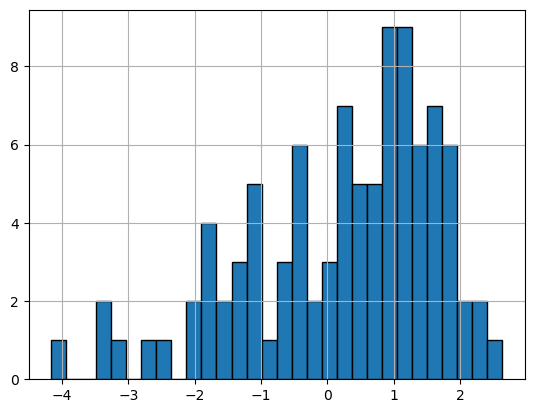

In [72]:
z_series.hist(bins=30, edgecolor='k')

In [99]:
class VIXRiskManager:
    """
    Monitors open positions and checks four exit conditions every cycle:
    1. Signal exit:  z-score reverts inside exit band → take profit
    2. Stop loss:    z-score exceeds stop threshold → cut losses
    3. Max hold:     position held longer than max days → forced exit
    4. Regime exit:  VIX spikes above threshold → emergency exit
    """

    def __init__(self, exit_z: float = Z_EXIT, stop_z: float = Z_STOP,
                 max_hold: int = MAX_HOLD_DAYS, regime_threshold: float = VIX_REGIME_THRESHOLD):
        self.exit_z = exit_z
        self.stop_z = stop_z
        self.max_hold = max_hold
        self.regime_threshold = regime_threshold

    def check_exit(self, position: dict, current_z: float, vix_spot: float, verbose: bool = VERBOSE) -> dict:
        """
        Check all four exit conditions for an open position.

        Args:
            position: dict with keys 'direction' (+1/-1), 'entry_date', 'entry_spread', 'entry_z'
            current_z: current z-score
            vix_spot: current VIX spot level

        Returns:
            dict with 'should_exit' (bool), 'reason' (str), 'details' (str)
        """
        direction = position['direction']  # +1 for long spread, -1 for short spread
        entry_date = position['entry_date']
        days_held = (datetime.now() - entry_date).days

        result = {'should_exit': False, 'reason': '', 'details': ''}

        # Layer 1: Signal exit — z-score reverted to within exit band
        if direction > 0 and current_z >= -self.exit_z:
            result = {'should_exit': True, 'reason': 'SIGNAL_EXIT',
                      'details': f'Z={current_z:.2f} reverted above -{self.exit_z} (long spread profit taken)'}

        elif direction < 0 and current_z <= self.exit_z:
            result = {'should_exit': True, 'reason': 'SIGNAL_EXIT',
                      'details': f'Z={current_z:.2f} reverted below +{self.exit_z} (short spread profit taken)'}

        # Layer 2: Stop loss — z-score went further against us
        elif direction > 0 and current_z <= -self.stop_z:
            result = {'should_exit': True, 'reason': 'STOP_LOSS',
                      'details': f'Z={current_z:.2f} <= -{self.stop_z} (spread diverging further, stop hit)'}

        elif direction < 0 and current_z >= self.stop_z:
            result = {'should_exit': True, 'reason': 'STOP_LOSS',
                      'details': f'Z={current_z:.2f} >= +{self.stop_z} (spread diverging further, stop hit)'}

        # Layer 3: Max hold timeout
        elif days_held >= self.max_hold:
            result = {'should_exit': True, 'reason': 'MAX_HOLD',
                      'details': f'Held {days_held} days >= {self.max_hold} max hold'}

        # Layer 4: Regime exit — VIX spiked above threshold while in position
        elif vix_spot >= self.regime_threshold:
            result = {'should_exit': True, 'reason': 'REGIME_EXIT',
                      'details': f'VIX={vix_spot:.1f} >= {self.regime_threshold} (environment changed)'}

        if verbose and result['should_exit']:
            dir_str = 'LONG' if direction > 0 else 'SHORT'
            print(f"[EXIT] {dir_str} spread | {result['reason']}: {result['details']}")

        return result


In [97]:
# === Step 7: VIXRiskManager 四层退出测试 ===
from datetime import datetime, timedelta
risk_mgr = VIXRiskManager()


In [93]:
# --- Layer 1: Signal Exit（止盈）---
# 模拟 LONG 仓，z 从 -2.0 回归到 -0.3
pos_long = {'direction': 1, 'entry_date': datetime.now() - timedelta(days=3),
            'entry_spread': -0.9, 'entry_z': -2.0}
r = risk_mgr.check_exit(pos_long, current_z=-0.3, vix_spot=20.0)
assert r['should_exit'] and r['reason'] == 'SIGNAL_EXIT'
print(f"✅ Layer 1 LONG: {r['details']}")

[EXIT] LONG spread | SIGNAL_EXIT: Z=-0.30 reverted above -0.5 (long spread profit taken)
✅ Layer 1 LONG: Z=-0.30 reverted above -0.5 (long spread profit taken)


In [94]:
# 模拟 SHORT 仓，z 从 +2.0 回归到 +0.3
pos_short = {'direction': -1, 'entry_date': datetime.now() - timedelta(days=3),
             'entry_spread': 1.5, 'entry_z': 2.0}
r = risk_mgr.check_exit(pos_short, current_z=0.3, vix_spot=20.0)
assert r['should_exit'] and r['reason'] == 'SIGNAL_EXIT'
print(f"✅ Layer 1 SHORT: {r['details']}")

[EXIT] SHORT spread | SIGNAL_EXIT: Z=0.30 reverted below +0.5 (short spread profit taken)
✅ Layer 1 SHORT: Z=0.30 reverted below +0.5 (short spread profit taken)


In [98]:
# --- Layer 2: Stop Loss（止损）---
pos_long = {'direction': 1, 'entry_date': datetime.now() - timedelta(days=3),
            'entry_spread': -0.9, 'entry_z': -2.0}
r = risk_mgr.check_exit(pos_long, current_z=-3.5, vix_spot=20.0)
assert r['should_exit'] and r['reason'] == 'STOP_LOSS'
print(f"✅ Layer 2: {r['details']}")

[EXIT] LONG spread | STOP_LOSS: Z=-3.50 <= -3.5 (spread diverging further, stop hit)
✅ Layer 2: Z=-3.50 <= -3.5 (spread diverging further, stop hit)


In [100]:
# --- Layer 3: Max Hold（超时）---
pos_old = {'direction': 1, 'entry_date': datetime.now() - timedelta(days=30),
           'entry_spread': -0.9, 'entry_z': -2.0}
r = risk_mgr.check_exit(pos_old, current_z=-1.0, vix_spot=20.0)
assert r['should_exit'] and r['reason'] == 'MAX_HOLD'
print(f"✅ Layer 3: {r['details']}")


[EXIT] LONG spread | MAX_HOLD: Held 30 days >= 30 max hold
✅ Layer 3: Held 30 days >= 30 max hold


In [101]:
# --- Layer 4: Regime Exit（市场巨变）---
r = risk_mgr.check_exit(pos_long, current_z=-1.0, vix_spot=30.0)
assert r['should_exit'] and r['reason'] == 'REGIME_EXIT'
print(f"✅ Layer 4: {r['details']}")

# --- 无退出：正常持仓 ---
r = risk_mgr.check_exit(pos_long, current_z=-1.0, vix_spot=20.0)
assert not r['should_exit']
print(f"✅ No exit: 持仓正常，无退出触发")

[EXIT] LONG spread | REGIME_EXIT: VIX=30.0 >= 25 (environment changed)
✅ Layer 4: VIX=30.0 >= 25 (environment changed)
✅ No exit: 持仓正常，无退出触发


In [103]:
class PositionTracker:
    """
    Tracks the current open calendar spread position.
    Persists state to disk so positions survive restarts.
    """

    def __init__(self, state_file: str = "vix_position_state.json"):
        self._state_file = Path(state_file)
        self.position = None  # None = flat, dict = open position
        self.trade_log = []
        self._load_state()

    def _load_state(self):
        if self._state_file.exists():
            with open(self._state_file, 'r') as f:
                state = json.load(f)
            if state.get('position'):
                pos = state['position']
                pos['entry_date'] = datetime.fromisoformat(pos['entry_date'])
                self.position = pos
            self.trade_log = state.get('trade_log', [])
            print(f"[TRACKER] Loaded state. Position: {'OPEN' if self.position else 'FLAT'}, "
                  f"Trade history: {len(self.trade_log)} trades.")

    def _save_state(self):
        state = {
            'position': None,
            'trade_log': self.trade_log
        }
        if self.position:
            pos_copy = self.position.copy()
            pos_copy['entry_date'] = pos_copy['entry_date'].isoformat()
            state['position'] = pos_copy

        with open(self._state_file, 'w') as f:
            json.dump(state, f, indent=2, default=str)

    def open_position(self, direction: int, entry_spread: float, entry_z: float, contracts: int):
        """Record a new position opening."""
        self.position = {
            'direction': direction,       # +1 = long spread, -1 = short spread
            'entry_date': datetime.now(),
            'entry_spread': entry_spread,
            'entry_z': entry_z,
            'contracts': contracts,
            'prev_spread': entry_spread    # for daily MtM
        }
        self._save_state()

        dir_str = 'LONG' if direction > 0 else 'SHORT'
        print(f"[POSITION] Opened {dir_str} spread × {contracts} | "
              f"Entry spread: {entry_spread:.4f} | Z: {entry_z:.3f}")

    def close_position(self, exit_spread: float, exit_z: float, reason: str) -> dict:
        """Record position close and log the trade."""
        if not self.position:
            return {}

        pos = self.position
        pnl_per_unit = pos['direction'] * (exit_spread - pos['entry_spread'])
        total_pnl = pnl_per_unit * pos['contracts'] * CAPITAL_PER_SPREAD
        days_held = (datetime.now() - pos['entry_date']).days

        trade = {
            'entry_date': pos['entry_date'].isoformat(),
            'exit_date': datetime.now().isoformat(),
            'direction': 'LONG' if pos['direction'] > 0 else 'SHORT',
            'entry_spread': pos['entry_spread'],
            'exit_spread': exit_spread,
            'entry_z': pos['entry_z'],
            'exit_z': exit_z,
            'contracts': pos['contracts'],
            'pnl': round(total_pnl, 2),
            'pnl_per_unit': round(pnl_per_unit, 4),
            'days_held': days_held,
            'exit_reason': reason
        }

        self.trade_log.append(trade)
        self.position = None
        self._save_state()

        print(f"[CLOSED] {trade['direction']} spread | PnL: ${total_pnl:,.2f} | "
              f"Held: {days_held}d | Reason: {reason}")

        return trade

    def update_mtm(self, current_spread: float) -> float:
        """
        Update daily mark-to-market. Returns today's MtM P&L.
        Called once per day to track daily returns.
        """
        if not self.position:
            return 0.0

        prev = self.position.get('prev_spread', self.position['entry_spread'])
        daily_pnl = self.position['direction'] * (current_spread - prev) * \
                     self.position['contracts'] * CAPITAL_PER_SPREAD

        self.position['prev_spread'] = current_spread
        self._save_state()
        return daily_pnl

    @property
    def is_flat(self) -> bool:
        return self.position is None

    @property
    def is_long(self) -> bool:
        return self.position is not None and self.position['direction'] > 0

    @property
    def is_short(self) -> bool:
        return self.position is not None and self.position['direction'] < 0



In [104]:
# === Step 8: PositionTracker 测试 ===
import os

# 清理旧文件防干扰
if os.path.exists("vix_position_state.json"):
    os.remove("vix_position_state.json")

tracker = PositionTracker()
assert tracker.is_flat
print("✅ 初始状态: FLAT")

# 开仓
tracker.open_position(direction=1, entry_spread=-0.9, entry_z=-2.0, contracts=2)
assert tracker.is_long
assert not tracker.is_flat
print(f"✅ 开仓: LONG spread × 2, entry_spread={tracker.position['entry_spread']}")

# 每日盯市
daily_pnl = tracker.update_mtm(current_spread=-0.5)
print(f"✅ 盯市: daily PnL = ${daily_pnl:,.2f}")

# 平仓
trade = tracker.close_position(exit_spread=-0.3, exit_z=-0.4, reason='SIGNAL_EXIT')
assert tracker.is_flat
assert trade['pnl'] > 0
print(f"✅ 平仓: PnL=${trade['pnl']:,.2f}, 持仓{trade['days_held']}天, 原因={trade['exit_reason']}")

# 持久化验证
tracker2 = PositionTracker()
assert tracker2.is_flat
assert len(tracker2.trade_log) == 1
print(f"✅ 持久化: 重启后 trade_log 有 {len(tracker2.trade_log)} 条记录")

# 清理
os.remove("vix_position_state.json")
print("✅ Step 8 全部通过")

✅ 初始状态: FLAT
[POSITION] Opened LONG spread × 2 | Entry spread: -0.9000 | Z: -2.000
✅ 开仓: LONG spread × 2, entry_spread=-0.9
✅ 盯市: daily PnL = $800.00
[CLOSED] LONG spread | PnL: $1,200.00 | Held: 0d | Reason: SIGNAL_EXIT
✅ 平仓: PnL=$1,200.00, 持仓0天, 原因=SIGNAL_EXIT
[TRACKER] Loaded state. Position: FLAT, Trade history: 1 trades.
✅ 持久化: 重启后 trade_log 有 1 条记录
✅ Step 8 全部通过


In [115]:
class VIXStrategyEngine:
    """
    Main orchestrator. Runs the daily cycle:
    1. Fetch current VX1, VX2, VIX prices
    2. Update spread history
    3. If in position → check four-layer exit
    4. If flat → check for entry signal
    5. Execute trades if needed
    """

    def __init__(self, ibkr: IBKR, verbose: bool = VERBOSE):
        self.ibkr = ibkr  # IBKR wrapper — single entry point

        self.contract_mgr = VIXContractManager(ibkr)
        self.data_engine = VIXDataEngine(ibkr, self.contract_mgr)
        self.signal_engine = VIXSignalEngine(lookback=Z_LOOKBACK, entry_z=Z_ENTRY)
        self.risk_mgr = VIXRiskManager()
        self.tracker = PositionTracker()
        self.verbose = verbose

        # Contracts (resolved on first run)
        self.vx1_contract = None
        self.vx2_contract = None

        # Load persisted spread history
        self.data_engine.load_state()

    def _resolve_contracts(self):
        """Resolve front/second month VIX futures contracts."""
        self.vx1_contract, self.vx2_contract = self.contract_mgr.get_front_and_second_month()
        if not self.vx1_contract or not self.vx2_contract:
            raise RuntimeError("Failed to resolve VIX futures contracts.")

    def _check_roll_needed(self) -> bool:
        """Check if front month is too close to expiry and needs to roll."""
        if not self.vx1_contract:
            return True
        days = self.contract_mgr.days_to_expiry(self.vx1_contract)
        if days <= 3:
            print(f"[ROLL] VX1 expires in {days} days — re-resolving contracts.")
            return True
        return False

    def _handle_roll(self):
        """
        Handle contract roll. If holding a position:
        1. Close position with old contracts
        2. Re-resolve to new month contracts
        3. Re-open position with new contracts
        """
        if self.tracker.is_flat:
            self._resolve_contracts()
            return

        pos = self.tracker.position
        direction = pos['direction']
        contracts = pos['contracts']
        dir_str = 'LONG' if direction > 0 else 'SHORT'

        print(f"\n[ROLL] Rolling {dir_str} spread x {contracts} to new contracts...")

        # Step 1: Close old position
        if direction > 0:
            vx2_close, vx1_close = 'SELL', 'BUY'
        else:
            vx2_close, vx1_close = 'BUY', 'SELL'

        self.ibkr.place_order(self.vx2_contract, vx2_close, contracts)
        self.ibkr.place_order(self.vx1_contract, vx1_close, contracts)
        print(f"[ROLL] Closed: {vx2_close} {contracts} VX2 ({self.vx2_contract.localSymbol}), "
              f"{vx1_close} {contracts} VX1 ({self.vx1_contract.localSymbol})")

        # Step 2: Re-resolve contracts to new month
        old_vx1 = self.vx1_contract.localSymbol
        self._resolve_contracts()
        print(f"[ROLL] Contracts rolled: {old_vx1} -> {self.vx1_contract.localSymbol}")

        # Step 3: Re-open position with new contracts
        if direction > 0:
            vx2_open, vx1_open = 'BUY', 'SELL'
        else:
            vx2_open, vx1_open = 'SELL', 'BUY'

        self.ibkr.place_order(self.vx2_contract, vx2_open, contracts)
        self.ibkr.place_order(self.vx1_contract, vx1_open, contracts)
        print(f"[ROLL] Reopened: {vx2_open} {contracts} VX2 ({self.vx2_contract.localSymbol}), "
              f"{vx1_open} {contracts} VX1 ({self.vx1_contract.localSymbol})")

        # Update tracker with new spread level
        vx1_price = self.data_engine.fetch_current_price(self.vx1_contract)
        vx2_price = self.data_engine.fetch_current_price(self.vx2_contract)
        new_spread = vx2_price - vx1_price
        self.tracker.position['entry_spread'] = new_spread
        self.tracker.position['prev_spread'] = new_spread
        self.tracker.position['entry_date'] = pos['entry_date']
        self.tracker._save_state()
        print(f"[ROLL] New spread: {new_spread:.4f} | Position preserved.")

    def run_daily_cycle(self):
        """Main daily routine. Called once per day ~30 min before market close."""
        now = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        print(f"\n{'='*60}")
        print(f"  VIX Calendar Spread — Daily Cycle @ {now}")
        print(f"{'='*60}")

        # Step 0: Resolve or roll contracts
        if self._check_roll_needed():
            self._handle_roll()

        # Step 1: Fetch current prices
        vx1_price = self.data_engine.fetch_current_price(self.vx1_contract)
        vx2_price = self.data_engine.fetch_current_price(self.vx2_contract)
        vix_spot = self.data_engine.fetch_vix_spot()
        current_spread = vx2_price - vx1_price

        print(f"[PRICES] VX1: {vx1_price:.2f} | VX2: {vx2_price:.2f} | "
              f"Spread: {current_spread:.4f} | VIX: {vix_spot:.2f}")

        if math.isnan(vx1_price) or math.isnan(vx2_price):
            print("[ERROR] Price fetch failed. Skipping this cycle.")
            return

        # Step 2: Update spread history
        self.data_engine.update_spread_today(vx1_price, vx2_price, vix_spot)

        # Step 3: Compute z-score
        spread_history = self.data_engine.spread_history
        if len(spread_history) < Z_LOOKBACK + 1:
            print(f"[WAIT] Building spread history... ({len(spread_history)}/{Z_LOOKBACK + 1} days)")
            return

        z_series = self.signal_engine.compute_zscore(spread_history['spread'])
        current_z = z_series.iloc[-1]

        # Step 4: Daily MtM if we have an open position
        if not self.tracker.is_flat:
            daily_mtm = self.tracker.update_mtm(current_spread)
            print(f"[MTM] Daily P&L: ${daily_mtm:,.2f}")

        # Step 5: Check exits if in position
        if not self.tracker.is_flat:
            exit_result = self.risk_mgr.check_exit(
                self.tracker.position, current_z, vix_spot, verbose=self.verbose)

            if exit_result['should_exit']:
                self._execute_exit(current_spread, current_z, exit_result['reason'])
                return

        # Step 6: Check for entry if flat
        if self.tracker.is_flat:
            signal = self.signal_engine.generate_signal(spread_history, vix_spot, verbose=self.verbose)

            if signal['signal'] != 'NO_SIGNAL':
                self._execute_entry(signal, current_spread, current_z)

        print(f"{'='*60}\n")

    @staticmethod
    def _size_by_zscore(z: float) -> int:
        """Determine position size based on z-score magnitude."""
        az = abs(z)
        for threshold, size in POSITION_SIZE_TIERS:
            if az >= threshold:
                return size
        return 1

    def _execute_entry(self, signal: dict, current_spread: float, current_z: float):
        """Execute a new calendar spread entry."""
        direction = 1 if signal['signal'] == 'LONG_SPREAD' else -1
        dir_str = 'LONG' if direction > 0 else 'SHORT'
        contracts = self._size_by_zscore(current_z)

        print(f"\n{'='*60}")
        print(f"  NEW TRADE: {dir_str} SPREAD x {contracts}")
        print(f"  VX1 action: {'SELL' if direction > 0 else 'BUY'}")
        print(f"  VX2 action: {'BUY' if direction > 0 else 'SELL'}")
        print(f"  Spread: {current_spread:.4f} | Z-Score: {current_z:.3f}")
        print(f"  Notional: ${contracts * CAPITAL_PER_SPREAD:,.0f}")
        print(f"{'='*60}")

        if REQUIRE_APPROVAL:
            print("\a")
            user_input = input("Execute this trade? (y/n): ")
            if user_input.lower() != 'y':
                print("[CANCELLED] Trade not executed.")
                return

        if direction > 0:
            vx2_action, vx1_action = 'BUY', 'SELL'
        else:
            vx2_action, vx1_action = 'SELL', 'BUY'

        self.ibkr.place_order(self.vx2_contract, vx2_action, contracts)
        self.ibkr.place_order(self.vx1_contract, vx1_action, contracts)
        print(f"[EXEC] {vx2_action} {contracts} VX2 ({self.vx2_contract.localSymbol})")
        print(f"[EXEC] {vx1_action} {contracts} VX1 ({self.vx1_contract.localSymbol})")

        self.tracker.open_position(direction, current_spread, current_z, contracts)

    def _execute_exit(self, current_spread: float, current_z: float, reason: str):
        """Close the open calendar spread position."""
        pos = self.tracker.position
        direction = pos['direction']
        contracts = pos['contracts']

        if direction > 0:
            vx2_action, vx1_action = 'SELL', 'BUY'
        else:
            vx2_action, vx1_action = 'BUY', 'SELL'

        print(f"\n[EXIT EXECUTION] Closing spread — reason: {reason}")

        if REQUIRE_APPROVAL:
            print("\a")
            user_input = input(f"Confirm exit ({reason})? (y/n): ")
            if user_input.lower() != 'y':
                print("[DEFERRED] Exit not executed. Will check again next cycle.")
                return

        self.ibkr.place_order(self.vx2_contract, vx2_action, contracts)
        self.ibkr.place_order(self.vx1_contract, vx1_action, contracts)
        print(f"[EXEC] {vx2_action} {contracts} VX2 ({self.vx2_contract.localSymbol})")
        print(f"[EXEC] {vx1_action} {contracts} VX1 ({self.vx1_contract.localSymbol})")

        self.tracker.close_position(current_spread, current_z, reason)

    def routine_risk_check(self):
        """
        Intraday risk monitoring — runs all four exit layers every N minutes.
        Catches take profit, stop loss, max hold, and regime exit between daily cycles.
        """
        if self.tracker.is_flat:
            return

        if not self.vx1_contract or not self.vx2_contract:
            return

        # Fetch current market state
        vx1_price = self.data_engine.fetch_current_price(self.vx1_contract)
        vx2_price = self.data_engine.fetch_current_price(self.vx2_contract)
        vix_spot = self.data_engine.fetch_vix_spot()

        if math.isnan(vx1_price) or math.isnan(vx2_price):
            return

        current_spread = vx2_price - vx1_price

        # Compute current z-score
        spread_history = self.data_engine.spread_history
        if len(spread_history) < Z_LOOKBACK + 1:
            return

        z_series = self.signal_engine.compute_zscore(spread_history['spread'])
        current_z = z_series.iloc[-1] if len(z_series) > 0 else 0.0

        if self.verbose:
            now = datetime.now().strftime('%H:%M:%S')
            dir_str = 'LONG' if self.tracker.is_long else 'SHORT'
            print(f"[{now}] Risk check | Spread: {current_spread:.4f} | "
                  f"Z: {current_z:.3f} | VIX: {vix_spot:.2f} | Pos: {dir_str}")

        # Run all four exit layers
        exit_result = self.risk_mgr.check_exit(
            self.tracker.position, current_z, vix_spot, verbose=self.verbose)

        if exit_result['should_exit']:
            self._execute_exit(current_spread, current_z, exit_result['reason'])

In [119]:
from vix_config import *

In [121]:
POSITION_SIZE_TIERS = [
    (3.0, 5),   # |z| >= 3.0 → 5 contracts (full size)
    (2.5, 4),   # |z| >= 2.5 → 4 contracts
    (2.0, 3),   # |z| >= 2.0 → 3 contracts
    (1.5, 2),   # |z| >= 1.5 → 2 contracts (minimum entry)
]
# === Step 9: VIXStrategyEngine 离线测试 ===
engine = VIXStrategyEngine(ibkr=ib)
# --- 9a: _size_by_zscore ---
assert VIXStrategyEngine._size_by_zscore(-1.6) == 2
assert VIXStrategyEngine._size_by_zscore(-2.0) == 3
assert VIXStrategyEngine._size_by_zscore(2.5) == 4
assert VIXStrategyEngine._size_by_zscore(-3.5) == 5
assert VIXStrategyEngine._size_by_zscore(1.0) == 1  # fallback, below entry
print("✅ 9a: _size_by_zscore 分档正确")

# --- 9b: run_daily_cycle 需要连 IBKR ---
# engine = VIXStrategyEngine(ibkr=ib)
# engine.run_daily_cycle()

# --- 9c: routine_risk_check 需要连 IBKR ---
# engine.routine_risk_check()

[DATA] Loaded 125 days of spread history from disk.
✅ 9a: _size_by_zscore 分档正确
